# Chimera Clinical EDA — Biochemical Recurrence (BCR) in Prostate Cancer

**Dataset:** 95 prostate-cancer patients from the Chimera dataset (Task 1)

**Goal:** Explore which clinical features separate BCR-positive from BCR-negative patients,
including survival/time-to-event analysis.

**Abbreviations:**
- **BCR:** Biochemical Recurrence (PSA rise after prostatectomy)
- **PSA:** Prostate-Specific Antigen
- **ISUP:** International Society of Urological Pathology grade group
- **pT:** Pathological Tumour stage
- **KM:** Kaplan-Meier

---
## Section 1: Data Loading & Cleaning

In [14]:
import json
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 120, "figure.max_open_warning": 0})

In [15]:
# Load all 95 clinical JSONs
json_files = sorted(glob.glob("../data/clinical_data/*.json"))
records = []
for f in json_files:
    with open(f) as fh:
        d = json.load(fh)
        d["patient_id"] = f.split("/")[-1].replace(".json", "")
        records.append(d)

df = pd.DataFrame(records)
print(f"Loaded {len(df)} patients, {len(df.columns)} fields")
df.head()

Loaded 95 patients, 17 fields


,age_at_prostatectomy,primary_gleason,secondary_gleason,tertiary_gleason,ISUP,pre_operative_PSA,BCR,BCR_PSA,time_to_follow-up/BCR,pT_stage,positive_lymph_nodes,capsular_penetration,positive_surgical_margins,invasion_seminal_vesicles,lymphovascular_invasion,earlier_therapy,patient_id
0,66,3,4,5.0,2,8.3,1.0,0.11,1.3,3b,1,1,1,1,1.0,none,1003
1,60,3,2,4.0,1,10.0,1.0,1.6,1.7,3a,x,x,1,0,1.0,none,1010
2,66,4,3,NaN,3,6.9,0.0,NaN,60.7,2c,x,0,0,0,0.0,none,1011
3,69,3,4,NaN,2,15.0,0.0,NaN,60.6,3a,x,1,0,0,1.0,none,1021
4,65,3,4,NaN,2,5.2,0.0,NaN,62.3,2c,x,0,0,0,0.0,none,1025


In [16]:
# --- Type fixes ---

# BCR: "0.0"/"1.0" → int
df["BCR"] = df["BCR"].astype(float).astype(int)

# BCR_PSA: ' ' and missing → NaN, rest → float
df["BCR_PSA"] = pd.to_numeric(df["BCR_PSA"], errors="coerce")

# positive_lymph_nodes, capsular_penetration: "x" → NaN, rest → int
for col in ["positive_lymph_nodes", "capsular_penetration"]:
    df[col] = df[col].replace("x", np.nan)
    df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

# invasion_seminal_vesicles: string → int
df["invasion_seminal_vesicles"] = df["invasion_seminal_vesicles"].astype(int)

# lymphovascular_invasion: "0.0"/"1.0" → int
df["lymphovascular_invasion"] = df["lymphovascular_invasion"].astype(float).astype(int)

# pT_stage: ordered categorical
stage_order = ["2", "2a", "2c", "3a", "3b", "4", "4b"]
df["pT_stage"] = pd.Categorical(df["pT_stage"], categories=stage_order, ordered=True)

# tertiary_gleason → nullable int
df["tertiary_gleason"] = df["tertiary_gleason"].astype("Int64")

print("Type conversions complete.")
df.dtypes

Type conversions complete.


age_at_prostatectomy            int64
primary_gleason                 int64
secondary_gleason               int64
tertiary_gleason                Int64
ISUP                            int64
pre_operative_PSA             float64
BCR                             int64
BCR_PSA                       float64
time_to_follow-up/BCR         float64
pT_stage                     category
positive_lymph_nodes            Int64
capsular_penetration            Int64
positive_surgical_margins       int64
invasion_seminal_vesicles       int64
lymphovascular_invasion         int64
earlier_therapy                   str
patient_id                        str
dtype: object

In [17]:
# --- Data quality summary ---
quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(1),
    "n_unique": df.nunique(),
    "example_values": [df[c].dropna().unique()[:5].tolist() for c in df.columns],
})
quality

,dtype,non_null,missing,pct_missing,n_unique,example_values
age_at_prostatectomy,int64,95,0,0.0,24,"[66, 60, 69, 65, 72]"
primary_gleason,int64,95,0,0.0,3,"[3, 4, 5]"
secondary_gleason,int64,95,0,0.0,4,"[4, 2, 3, 5]"
tertiary_gleason,Int64,20,75,78.9,3,"[5, 4, 3]"
ISUP,int64,95,0,0.0,5,"[2, 1, 3, 4, 5]"
pre_operative_PSA,float64,95,0,0.0,73,"[8.3, 10.0, 6.9, 15.0, 5.2]"
BCR,int64,95,0,0.0,2,"[1, 0]"
BCR_PSA,float64,27,68,71.6,19,"[0.11, 1.6, 0.8, 0.23, 0.1]"
time_to_follow-up/BCR,float64,95,0,0.0,82,"[1.3, 1.7, 60.7, 60.6, 62.3]"
pT_stage,category,95,0,0.0,7,"[3b, 3a, 2c, 2, 4]"


---
## Section 2: Cohort Overview

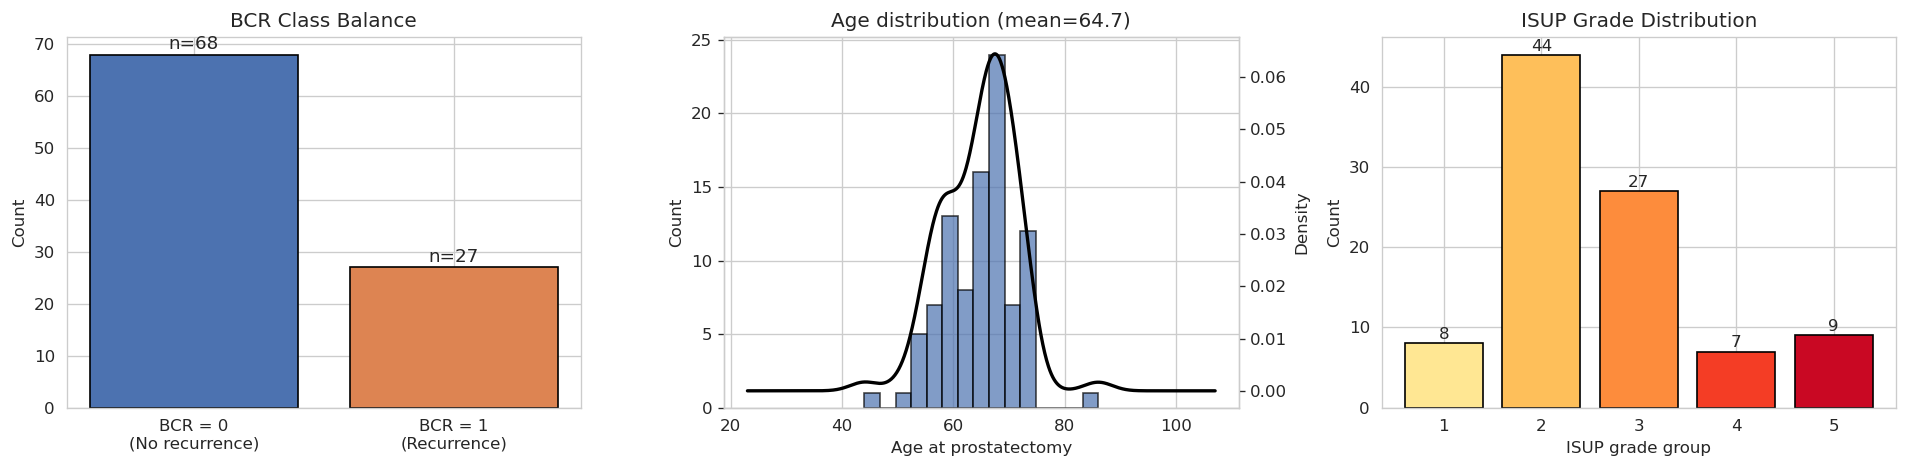

In [18]:
# BCR class balance
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) BCR bar chart
bcr_counts = df["BCR"].value_counts().sort_index()
ax = axes[0]
bars = ax.bar(["BCR = 0\n(No recurrence)", "BCR = 1\n(Recurrence)"],
              bcr_counts.values, color=["#4c72b0", "#dd8452"], edgecolor="black")
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 1,
            f"n={int(b.get_height())}", ha="center", fontsize=11)
ax.set_ylabel("Count")
ax.set_title("BCR Class Balance")

# (b) Age distribution
ax = axes[1]
ax.hist(df["age_at_prostatectomy"], bins=15, color="#4c72b0", edgecolor="black", alpha=0.7)
df["age_at_prostatectomy"].plot.kde(ax=ax, secondary_y=True, color="black", linewidth=2)
ax.set_xlabel("Age at prostatectomy")
ax.set_ylabel("Count")
ax.set_title(f"Age distribution (mean={df['age_at_prostatectomy'].mean():.1f})")
ax.right_ax.set_ylabel("Density")

# (c) ISUP grade distribution
ax = axes[2]
isup_counts = df["ISUP"].value_counts().sort_index()
ax.bar(isup_counts.index.astype(str), isup_counts.values,
       color=sns.color_palette("YlOrRd", len(isup_counts)), edgecolor="black")
for i, v in enumerate(isup_counts.values):
    ax.text(i, v + 0.5, str(v), ha="center", fontsize=10)
ax.set_xlabel("ISUP grade group")
ax.set_ylabel("Count")
ax.set_title("ISUP Grade Distribution")

plt.tight_layout()
plt.show()

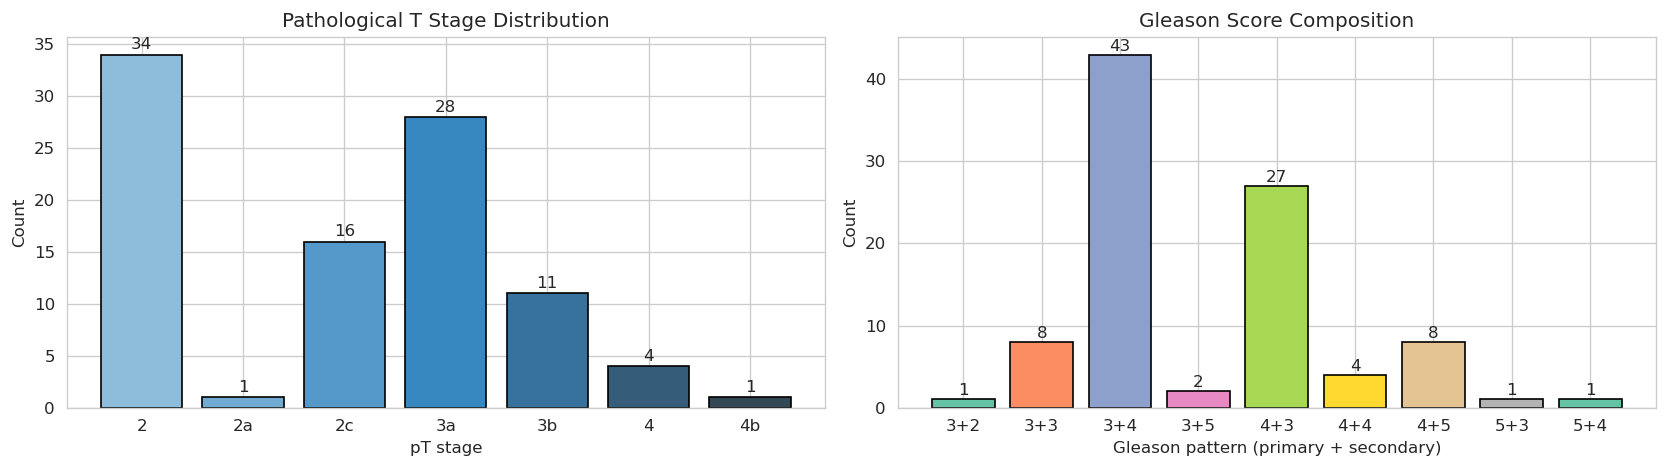

In [19]:
# pT stage distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
stage_counts = df["pT_stage"].value_counts().sort_index()
ax.bar(stage_counts.index.astype(str), stage_counts.values,
       color=sns.color_palette("Blues_d", len(stage_counts)), edgecolor="black")
for i, v in enumerate(stage_counts.values):
    ax.text(i, v + 0.5, str(v), ha="center", fontsize=10)
ax.set_xlabel("pT stage")
ax.set_ylabel("Count")
ax.set_title("Pathological T Stage Distribution")

# Gleason score composition
ax = axes[1]
df["gleason_sum"] = df["primary_gleason"] + df["secondary_gleason"]
df["gleason_label"] = df["primary_gleason"].astype(str) + "+" + df["secondary_gleason"].astype(str)
gleason_counts = df["gleason_label"].value_counts().sort_index()
ax.bar(gleason_counts.index, gleason_counts.values,
       color=sns.color_palette("Set2", len(gleason_counts)), edgecolor="black")
for i, v in enumerate(gleason_counts.values):
    ax.text(i, v + 0.5, str(v), ha="center", fontsize=10)
ax.set_xlabel("Gleason pattern (primary + secondary)")
ax.set_ylabel("Count")
ax.set_title("Gleason Score Composition")

plt.tight_layout()
plt.show()

In [20]:
# Prior therapy breakdown
print("Earlier therapy breakdown:")
print(df["earlier_therapy"].value_counts().to_frame("count"))
print(f"\n{(df['earlier_therapy'] == 'none').mean()*100:.1f}% had no prior therapy")

# Tertiary Gleason
n_tert = df["tertiary_gleason"].notna().sum()
print(f"\nTertiary Gleason present in {n_tert}/{len(df)} ({n_tert/len(df)*100:.1f}%) patients")
print(df["tertiary_gleason"].dropna().value_counts().to_frame("count"))

Earlier therapy breakdown:
                            count
earlier_therapy                  
none                           92
unknown                         1
radiotherapy + hormones         1
radiotherapy + cryotherapy      1

96.8% had no prior therapy

Tertiary Gleason present in 20/95 (21.1%) patients
                  count
tertiary_gleason       
5                    15
4                     3
3                     2


Too insanely low a sample size. I don't think this is going to be a useful label/column

---
## Section 3: Continuous Variable Distributions — BCR-Stratified

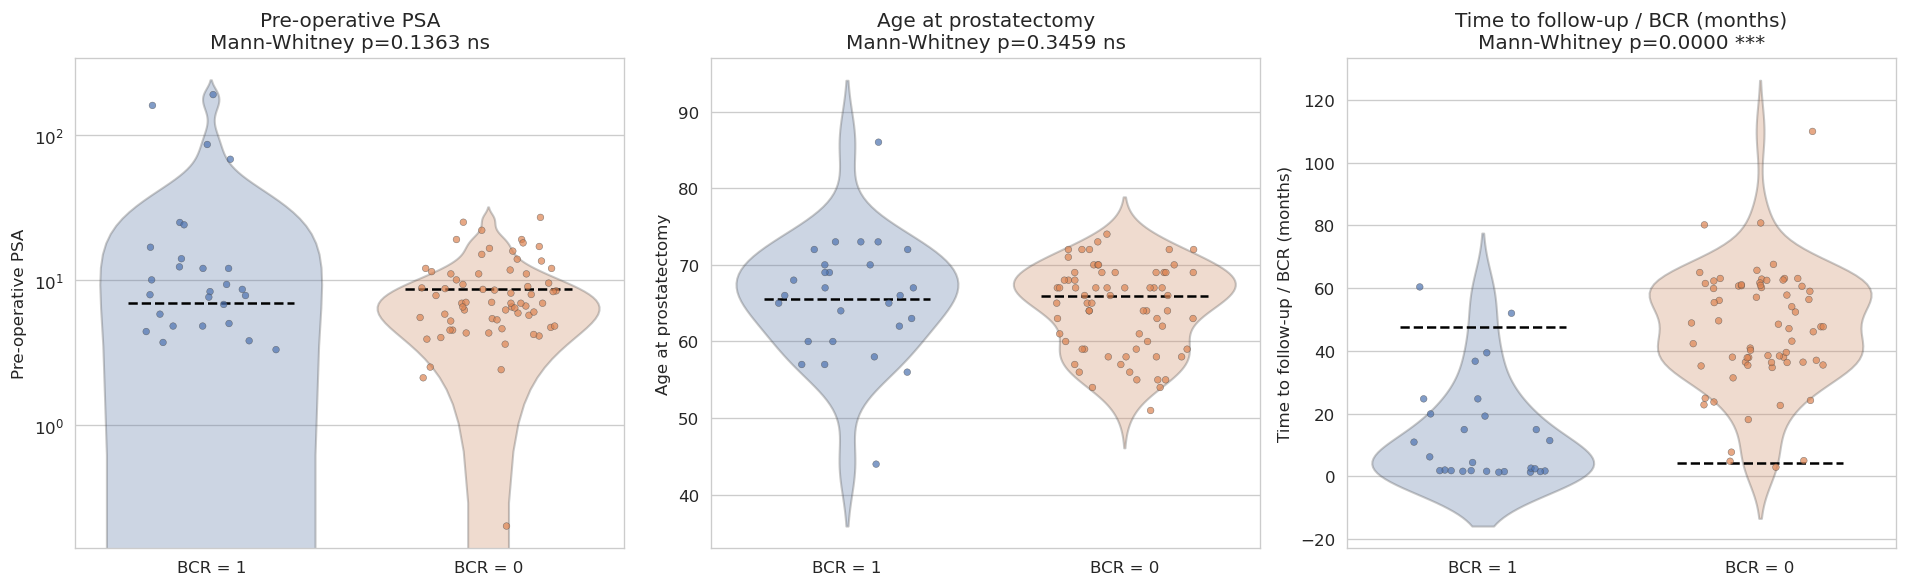

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cont_vars = [
    ("pre_operative_PSA", "Pre-operative PSA", True),
    ("age_at_prostatectomy", "Age at prostatectomy", False),
    ("time_to_follow-up/BCR", "Time to follow-up / BCR (months)", False),
]

for ax, (col, label, use_log) in zip(axes, cont_vars):
    plot_df = df[["BCR", col]].dropna()
    plot_df["BCR_label"] = plot_df["BCR"].map({0: "BCR = 0", 1: "BCR = 1"})

    sns.violinplot(data=plot_df, x="BCR_label", y=col, inner=None,
                   palette=["#4c72b0", "#dd8452"], ax=ax, alpha=0.3)
    sns.stripplot(data=plot_df, x="BCR_label", y=col,
                  palette=["#4c72b0", "#dd8452"], ax=ax,
                  size=4, jitter=0.25, alpha=0.7, edgecolor="gray", linewidth=0.3)
    if use_log:
        ax.set_yscale("log")
    ax.set_ylabel(label)
    ax.set_xlabel("")

    # Dashed median lines per group
    for i, bcr_val in enumerate([0, 1]):
        med = plot_df.loc[plot_df["BCR"] == bcr_val, col].median()
        ax.hlines(med, i - 0.3, i + 0.3, colors="black", linestyles="dashed", linewidth=1.5)

    # Mann-Whitney U test
    g0 = plot_df.loc[plot_df["BCR"] == 0, col]
    g1 = plot_df.loc[plot_df["BCR"] == 1, col]
    u_stat, p_val = stats.mannwhitneyu(g0, g1, alternative="two-sided")
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
    ax.set_title(f"{label}\nMann-Whitney p={p_val:.4f} {sig}")

plt.tight_layout()
plt.show()

Note: The PSA violins look weird because the violins were computed on linear values but were graphed on log y axis because the values are heavily right-skewed. Surprisingly Age doesn't seem to show much bias at all worth correcting for.

In [22]:
# Summary table
print("Mann-Whitney U tests (BCR=0 vs BCR=1):")
print("-" * 65)
for col, label, _ in cont_vars:
    g0 = df.loc[df["BCR"] == 0, col].dropna()
    g1 = df.loc[df["BCR"] == 1, col].dropna()
    u, p = stats.mannwhitneyu(g0, g1, alternative="two-sided")
    print(f"  {label:40s}  median(0)={g0.median():7.1f}  median(1)={g1.median():7.1f}  p={p:.4f}")

Mann-Whitney U tests (BCR=0 vs BCR=1):
-----------------------------------------------------------------
  Pre-operative PSA                         median(0)=    7.0  median(1)=    8.6  p=0.1363
  Age at prostatectomy                      median(0)=   65.5  median(1)=   66.0  p=0.3459
  Time to follow-up / BCR (months)          median(0)=   47.7  median(1)=    4.4  p=0.0000


---
## Section 4: Categorical Features vs BCR

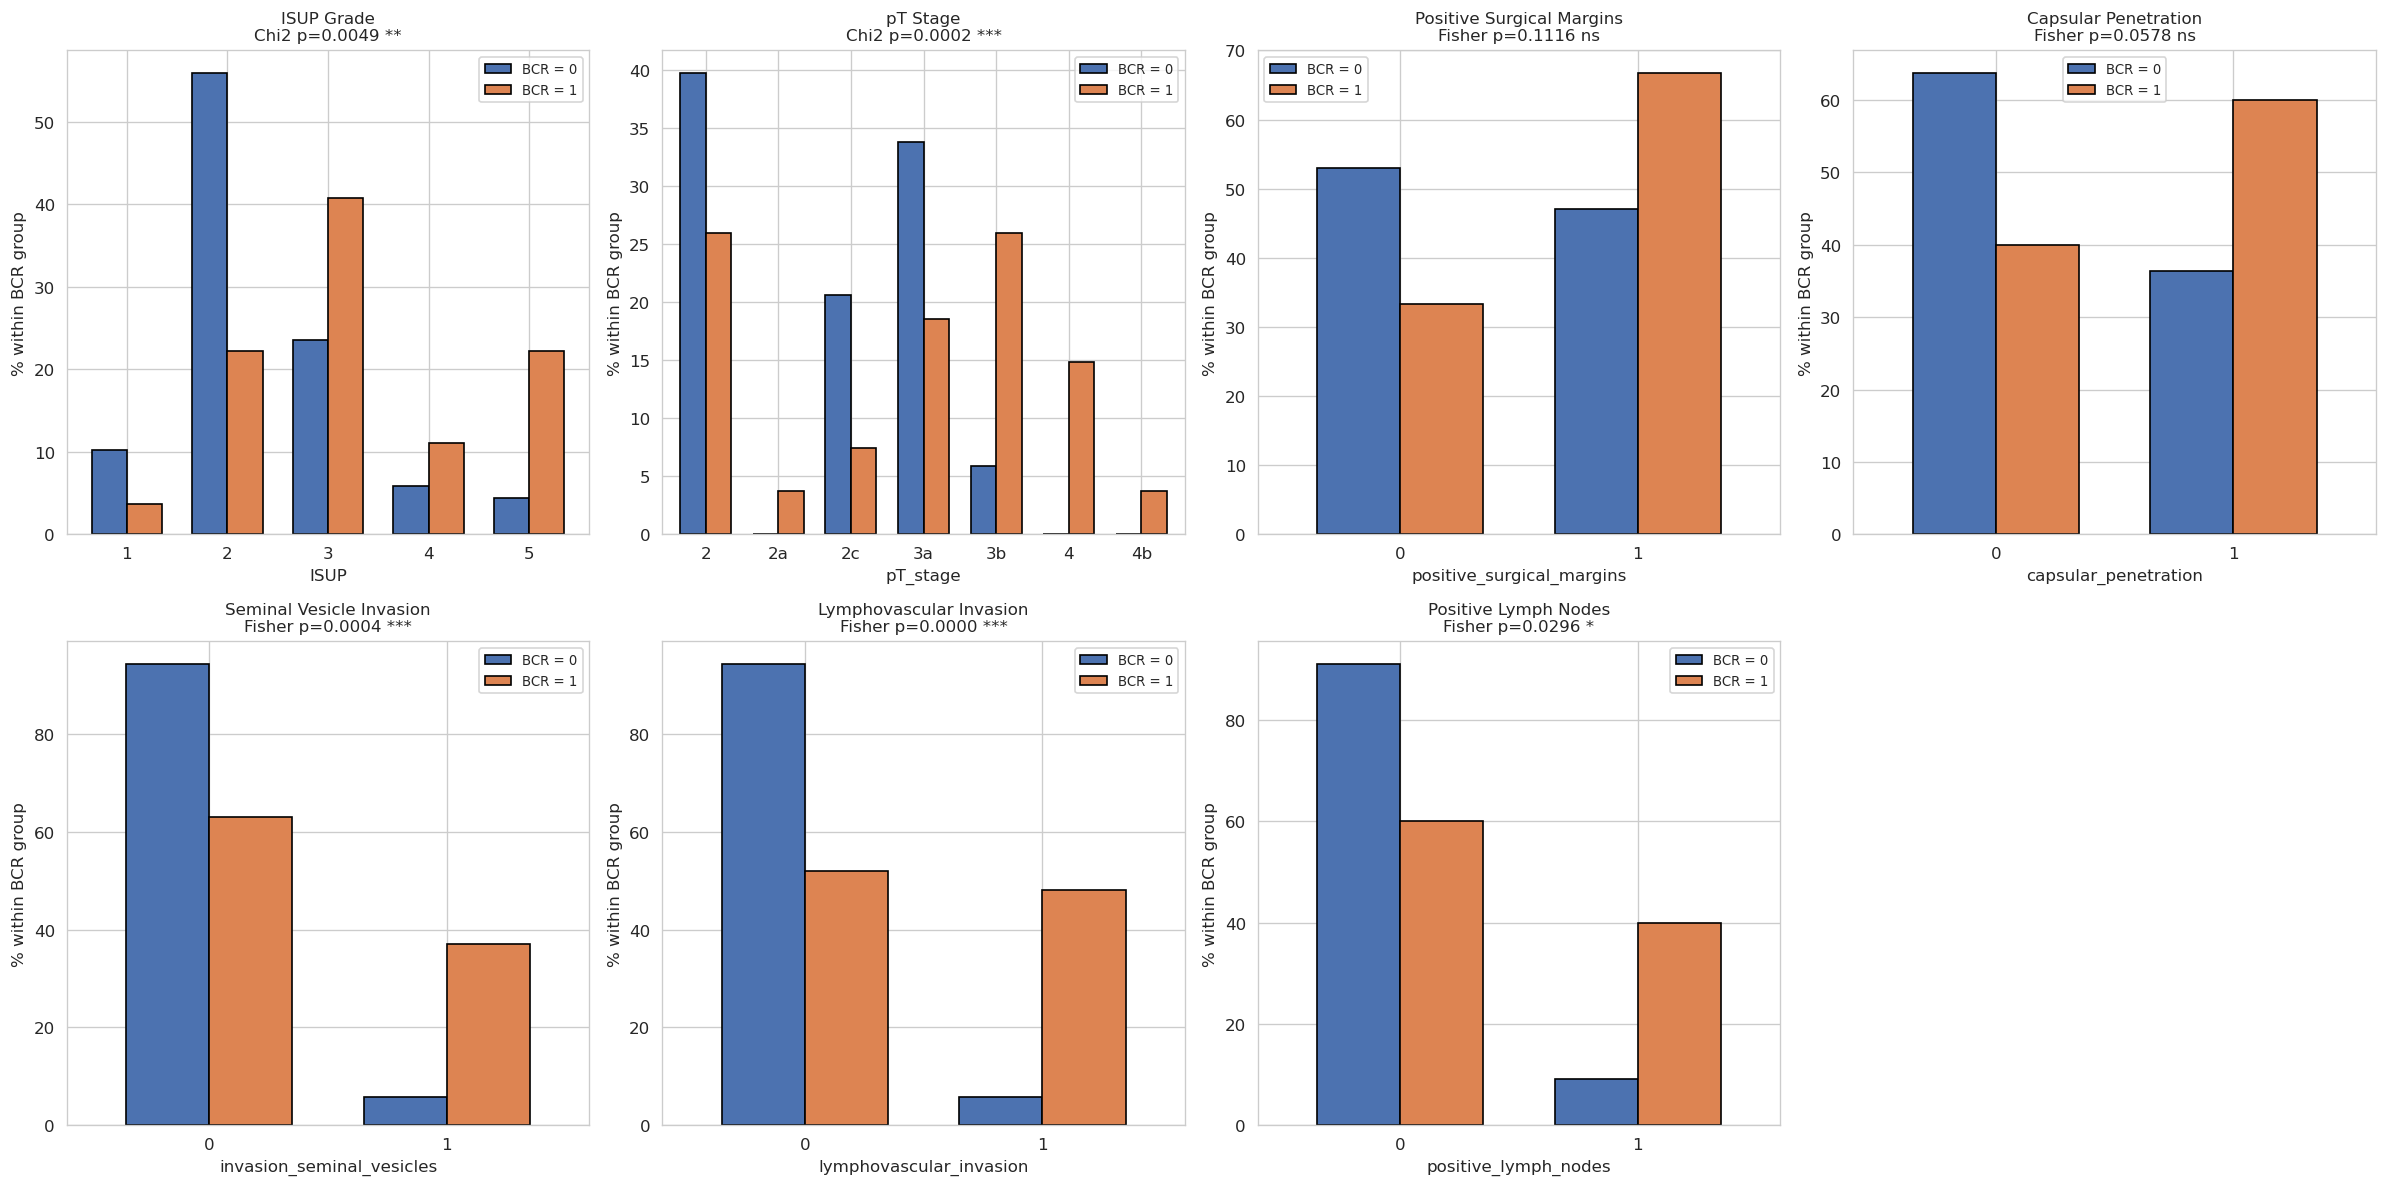

In [23]:
cat_features = [
    ("ISUP", "ISUP Grade"),
    ("pT_stage", "pT Stage"),
    ("positive_surgical_margins", "Positive Surgical Margins"),
    ("capsular_penetration", "Capsular Penetration"),
    ("invasion_seminal_vesicles", "Seminal Vesicle Invasion"),
    ("lymphovascular_invasion", "Lymphovascular Invasion"),
    ("positive_lymph_nodes", "Positive Lymph Nodes"),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

test_results = []

for idx, (col, label) in enumerate(cat_features):
    ax = axes[idx]
    sub = df[[col, "BCR"]].dropna()

    # Compute proportions within each BCR group
    ct = pd.crosstab(sub[col], sub["BCR"], normalize="columns") * 100
    ct.columns = ["BCR = 0", "BCR = 1"]

    ct.plot.bar(ax=ax, color=["#4c72b0", "#dd8452"], edgecolor="black", width=0.7)
    ax.set_ylabel("% within BCR group")
    ax.set_xlabel(col)
    ax.legend(fontsize=8)

    # Chi-squared or Fisher's exact test
    ct_raw = pd.crosstab(sub[col], sub["BCR"])
    if ct_raw.shape == (2, 2):
        odds, p_val = stats.fisher_exact(ct_raw)
        test_name = "Fisher"
    else:
        chi2, p_val, dof, _ = stats.chi2_contingency(ct_raw)
        test_name = "Chi2"

    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
    ax.set_title(f"{label}\n{test_name} p={p_val:.4f} {sig}", fontsize=10)
    ax.tick_params(axis="x", rotation=0)

    test_results.append({"Feature": label, "Test": test_name, "p-value": p_val, "Sig": sig})

# Remove extra subplot
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

In [24]:
# Summary table of statistical tests
test_df = pd.DataFrame(test_results).sort_values("p-value")
test_df.index = range(1, len(test_df) + 1)
print("Categorical features association with BCR (sorted by p-value):")
test_df

Categorical features association with BCR (sorted by p-value):


,Feature,Test,p-value,Sig
1,Lymphovascular Invasion,Fisher,0.000007,***
2,pT Stage,Chi2,0.000190,***
3,Seminal Vesicle Invasion,Fisher,0.000370,***
4,ISUP Grade,Chi2,0.004855,**
5,Positive Lymph Nodes,Fisher,0.029613,*
6,Capsular Penetration,Fisher,0.057769,ns
7,Positive Surgical Margins,Fisher,0.111605,ns


In [25]:
# Check expected frequencies for Chi-squared validity
print("Expected frequencies per feature (flagging any < 10):")
print("=" * 70)
for col, label in cat_features:
    sub = df[[col, "BCR"]].dropna()
    ct_raw = pd.crosstab(sub[col], sub["BCR"])
    if ct_raw.shape != (2, 2):
        chi2, p_val, dof, expected = stats.chi2_contingency(ct_raw)
        expected_df = pd.DataFrame(expected, index=ct_raw.index, columns=ct_raw.columns).round(1)
        n_low = (expected_df < 10).sum().sum()
        flag = f"  *** {n_low} entry/entries below 10 ***" if n_low > 0 else ""
        print(f"\n{label} (Chi2){flag}")
        print(expected_df.to_string())
    else:
        print(f"\n{label} (Fisher exact — no expected-frequency assumption)")

Expected frequencies per feature (flagging any < 10):

ISUP Grade (Chi2)  *** 7 entry/entries below 10 ***
BCR      0     1
ISUP            
1      5.7   2.3
2     31.5  12.5
3     19.3   7.7
4      5.0   2.0
5      6.4   2.6

pT Stage (Chi2)  *** 11 entry/entries below 10 ***
BCR          0    1
pT_stage           
2         24.3  9.7
2a         0.7  0.3
2c        11.5  4.5
3a        20.0  8.0
3b         7.9  3.1
4          2.9  1.1
4b         0.7  0.3

Positive Surgical Margins (Fisher exact — no expected-frequency assumption)

Capsular Penetration (Fisher exact — no expected-frequency assumption)

Seminal Vesicle Invasion (Fisher exact — no expected-frequency assumption)

Lymphovascular Invasion (Fisher exact — no expected-frequency assumption)

Positive Lymph Nodes (Fisher exact — no expected-frequency assumption)


---
## Section 5: Survival Analysis (Kaplan-Meier) (This section is weird so I'm still working on it. Skip it)

In [26]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# Event = BCR, time = time_to_follow-up/BCR
T = df["time_to_follow-up/BCR"]
E = df["BCR"]

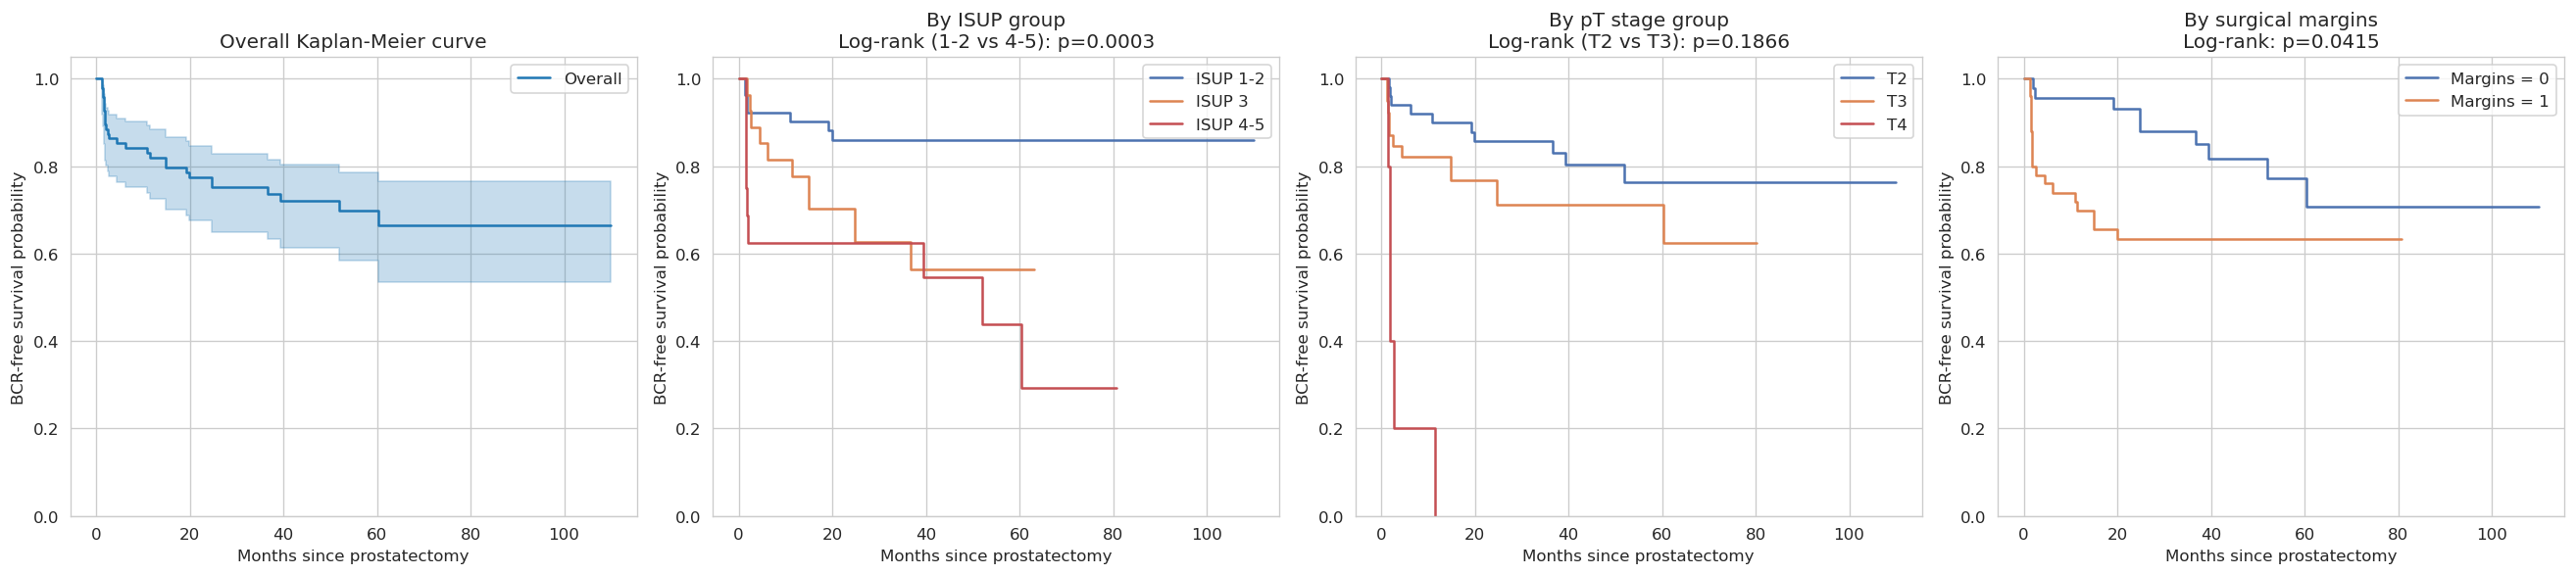

In [27]:
# Overall KM curve
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

kmf = KaplanMeierFitter()
ax = axes[0]
kmf.fit(T, event_observed=E, label="Overall")
kmf.plot_survival_function(ax=ax, ci_show=True)
ax.set_xlabel("Months since prostatectomy")
ax.set_ylabel("BCR-free survival probability")
ax.set_title("Overall Kaplan-Meier curve")
ax.set_ylim(0, 1.05)

# KM stratified by ISUP groups
ax = axes[1]
df["ISUP_group"] = pd.cut(df["ISUP"], bins=[0, 2, 3, 5],
                           labels=["ISUP 1-2", "ISUP 3", "ISUP 4-5"])
colors_isup = ["#4c72b0", "#dd8452", "#c44e52"]
groups_isup = df["ISUP_group"].dropna().unique().sort_values()
for g, c in zip(groups_isup, colors_isup):
    mask = df["ISUP_group"] == g
    kmf.fit(T[mask], event_observed=E[mask], label=str(g))
    kmf.plot_survival_function(ax=ax, ci_show=False, color=c)

# Log-rank test across groups
g1_mask = df["ISUP_group"] == "ISUP 1-2"
g2_mask = df["ISUP_group"] == "ISUP 3"
g3_mask = df["ISUP_group"] == "ISUP 4-5"
# Pairwise: low vs high
lr = logrank_test(T[g1_mask], T[g3_mask], E[g1_mask], E[g3_mask])
ax.set_xlabel("Months since prostatectomy")
ax.set_ylabel("BCR-free survival probability")
ax.set_title(f"By ISUP group\nLog-rank (1-2 vs 4-5): p={lr.p_value:.4f}")
ax.set_ylim(0, 1.05)

# KM stratified by pT stage groups
ax = axes[2]
df["pT_group"] = df["pT_stage"].apply(
    lambda x: "T2" if str(x).startswith("2") else ("T3" if str(x).startswith("3") else "T4"))
df["pT_group"] = pd.Categorical(df["pT_group"], categories=["T2", "T3", "T4"], ordered=True)
colors_pt = ["#4c72b0", "#dd8452", "#c44e52"]
for g, c in zip(["T2", "T3", "T4"], colors_pt):
    mask = df["pT_group"] == g
    if mask.sum() > 0:
        kmf.fit(T[mask], event_observed=E[mask], label=str(g))
        kmf.plot_survival_function(ax=ax, ci_show=False, color=c)

t2_mask = df["pT_group"] == "T2"
t3_mask = df["pT_group"] == "T3"
lr_pt = logrank_test(T[t2_mask], T[t3_mask], E[t2_mask], E[t3_mask])
ax.set_xlabel("Months since prostatectomy")
ax.set_ylabel("BCR-free survival probability")
ax.set_title(f"By pT stage group\nLog-rank (T2 vs T3): p={lr_pt.p_value:.4f}")
ax.set_ylim(0, 1.05)

# KM stratified by positive surgical margins
ax = axes[3]
colors_sm = ["#4c72b0", "#dd8452"]
for val, lab, c in [(0, "Margins = 0", colors_sm[0]), (1, "Margins = 1", colors_sm[1])]:
    mask = df["positive_surgical_margins"] == val
    kmf.fit(T[mask], event_observed=E[mask], label=lab)
    kmf.plot_survival_function(ax=ax, ci_show=False, color=c)

lr_sm = logrank_test(
    T[df["positive_surgical_margins"] == 0], T[df["positive_surgical_margins"] == 1],
    E[df["positive_surgical_margins"] == 0], E[df["positive_surgical_margins"] == 1])
ax.set_xlabel("Months since prostatectomy")
ax.set_ylabel("BCR-free survival probability")
ax.set_title(f"By surgical margins\nLog-rank: p={lr_sm.p_value:.4f}")
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

In [28]:
print("Log-rank test summary:")
print(f"  ISUP 1-2 vs 4-5:           p = {lr.p_value:.4f}")
print(f"  pT stage T2 vs T3:         p = {lr_pt.p_value:.4f}")
print(f"  Surgical margins 0 vs 1:   p = {lr_sm.p_value:.4f}")

Log-rank test summary:
  ISUP 1-2 vs 4-5:           p = 0.0003
  pT stage T2 vs T3:         p = 0.1866
  Surgical margins 0 vs 1:   p = 0.0415


Worse pathology leads to worse survival. Not surprising at all. However, this can be a point of concern if we are building models to predict outcomes from images and all the model does is predict stage. 

---
## Section 6: Correlation Structure

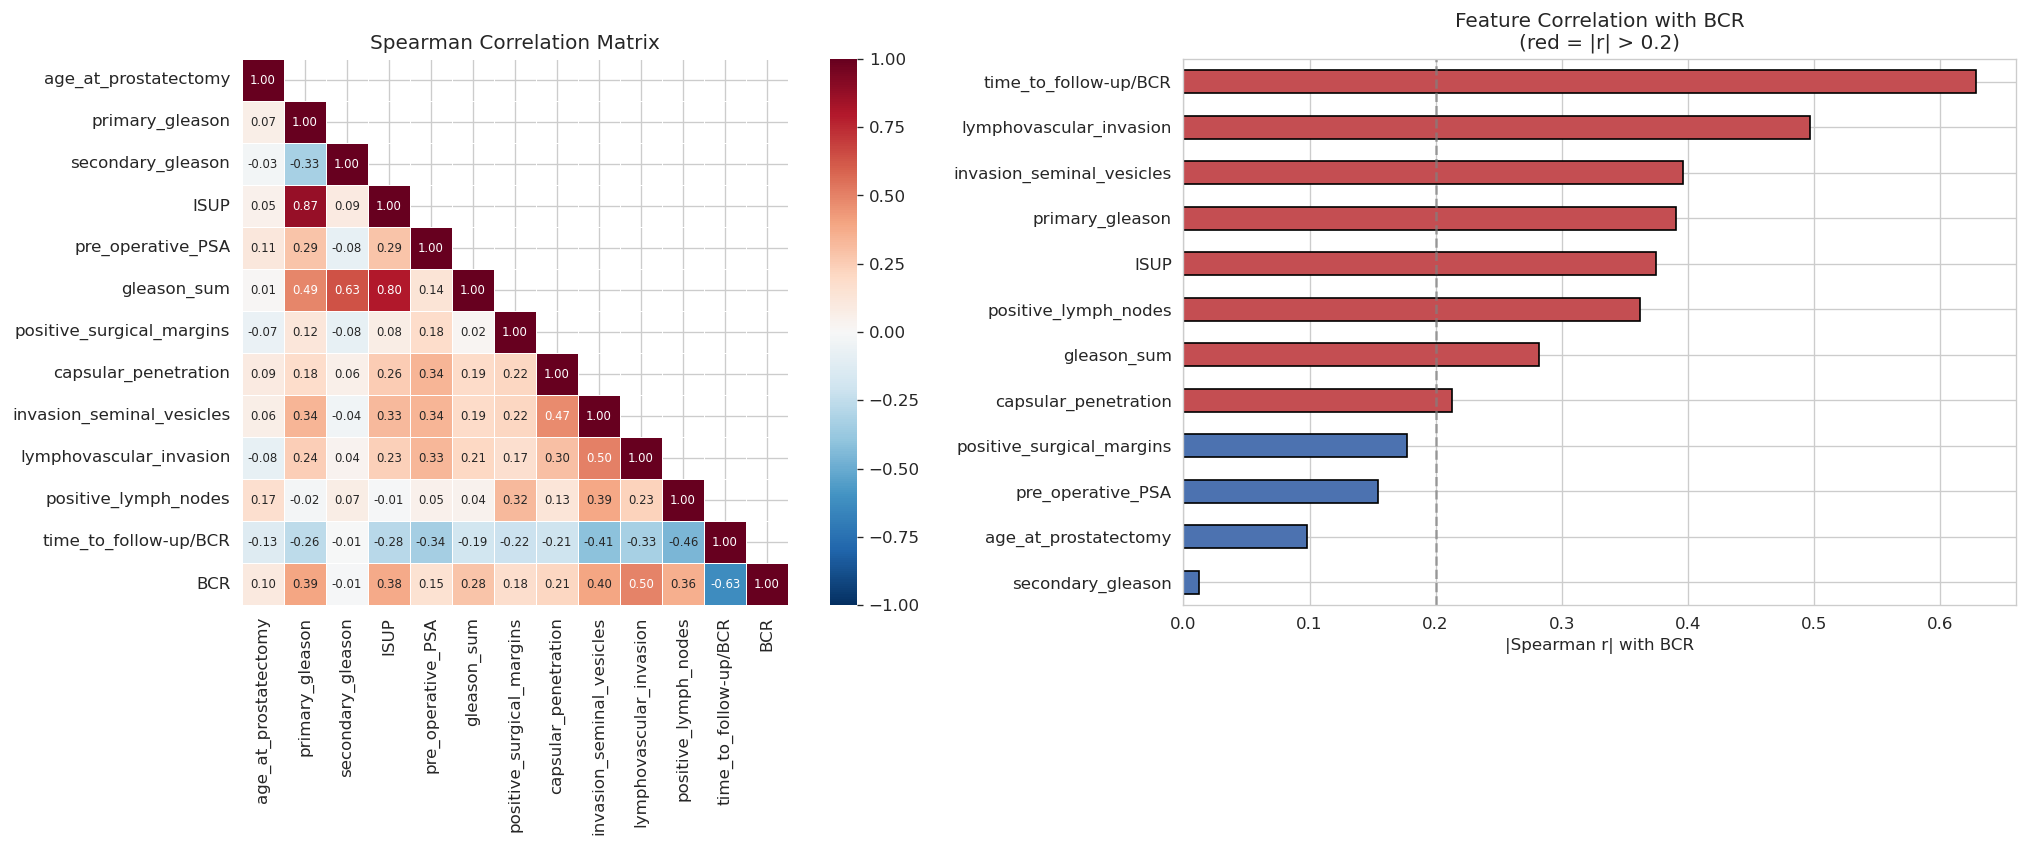

In [29]:
# Select numeric / binary features for correlation
corr_cols = [
    "age_at_prostatectomy", "primary_gleason", "secondary_gleason",
    "ISUP", "pre_operative_PSA", "gleason_sum",
    "positive_surgical_margins", "capsular_penetration",
    "invasion_seminal_vesicles", "lymphovascular_invasion",
    "positive_lymph_nodes", "time_to_follow-up/BCR", "BCR",
]

corr_df = df[corr_cols].apply(pd.to_numeric, errors="coerce")
corr_matrix = corr_df.corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# (a) Full heatmap
ax = axes[0]
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            ax=ax, annot_kws={"fontsize": 7})
ax.set_title("Spearman Correlation Matrix", fontsize=12)

# (b) Features ranked by absolute correlation with BCR
ax = axes[1]
bcr_corr = corr_matrix["BCR"].drop("BCR").abs().sort_values(ascending=True)
colors = ["#c44e52" if v > 0.2 else "#4c72b0" for v in bcr_corr.values]
bcr_corr.plot.barh(ax=ax, color=colors, edgecolor="black")
ax.set_xlabel("|Spearman r| with BCR")
ax.set_title("Feature Correlation with BCR\n(red = |r| > 0.2)")
ax.axvline(0.2, color="gray", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

In [30]:
# Print ranked correlations with BCR (including sign)
bcr_corr_signed = corr_matrix["BCR"].drop("BCR").sort_values(key=abs, ascending=False)
print("Spearman correlations with BCR (ranked by |r|):")
for feat, r in bcr_corr_signed.items():
    print(f"  {feat:35s}  r = {r:+.3f}")

Spearman correlations with BCR (ranked by |r|):
  time_to_follow-up/BCR                r = -0.629
  lymphovascular_invasion              r = +0.497
  invasion_seminal_vesicles            r = +0.396
  primary_gleason                      r = +0.391
  ISUP                                 r = +0.375
  positive_lymph_nodes                 r = +0.362
  gleason_sum                          r = +0.282
  capsular_penetration                 r = +0.213
  positive_surgical_margins            r = +0.177
  pre_operative_PSA                    r = +0.154
  age_at_prostatectomy                 r = +0.098
  secondary_gleason                    r = -0.012


---
## Section 7: Key Takeaways

### Features most associated with BCR
- **Time-to-event** is strongly associated by definition — BCR+ patients have shorter follow-up
  (they experienced the event earlier).
- **Pathological stage (pT)** and **seminal vesicle invasion** show strong separation between
  BCR groups both in proportion tests and Kaplan-Meier analysis.
- **ISUP grade / Gleason** — higher grades are enriched in BCR+ patients. The KM curves
  separate clearly between ISUP 1-2 vs 4-5.
- **Positive surgical margins** and **capsular penetration** are more frequent in BCR+ patients.
- **Pre-operative PSA** shows a trend toward higher values in BCR+ patients (check p-value above).
- **Age** is not a strong discriminator of BCR in this cohort.

### Data quality notes
- `tertiary_gleason` is only present in 21% of patients — too sparse for a standalone feature,
  but could be used as a binary indicator (present vs absent).
- `BCR_PSA` is only available for BCR+ patients (by definition) — not useful as a predictor,
  but describes the BCR event.
- `positive_lymph_nodes` and `capsular_penetration` have `"x"` values → NaN for ~5-10% of patients.
- `earlier_therapy`: 97% had no prior therapy — minimal variation, unlikely to be informative.

---
## Section 8: Whole Slide Image Inventory

In [31]:
from pathlib import Path
from collections import defaultdict

thumb_dir = Path("../previews/thumb")

counts = defaultdict(int)
for f in thumb_dir.glob("*.png"):
    patient = "_".join(f.stem.split("_")[:-1])
    counts[patient] += 1

slide_df = (
    pd.Series(counts, name="n_slides")
    .rename_axis("patient_id")
    .reset_index()
    .sort_values("patient_id")
    .reset_index(drop=True)
)
slide_df["patient_id"] = slide_df["patient_id"].astype(int)
slide_df = slide_df.sort_values("patient_id").reset_index(drop=True)

print(f"Patients with WSI: {len(slide_df)}")
print(f"Total slides:      {slide_df['n_slides'].sum()}")
print(f"Mean per patient:  {slide_df['n_slides'].mean():.2f}")
print(slide_df["n_slides"].value_counts().sort_index().to_frame("n_patients"))

Patients with WSI: 95
Total slides:      190
Mean per patient:  2.00
          n_patients
n_slides            
1                 38
2                 37
3                 11
4                  7
5                  1
12                 1


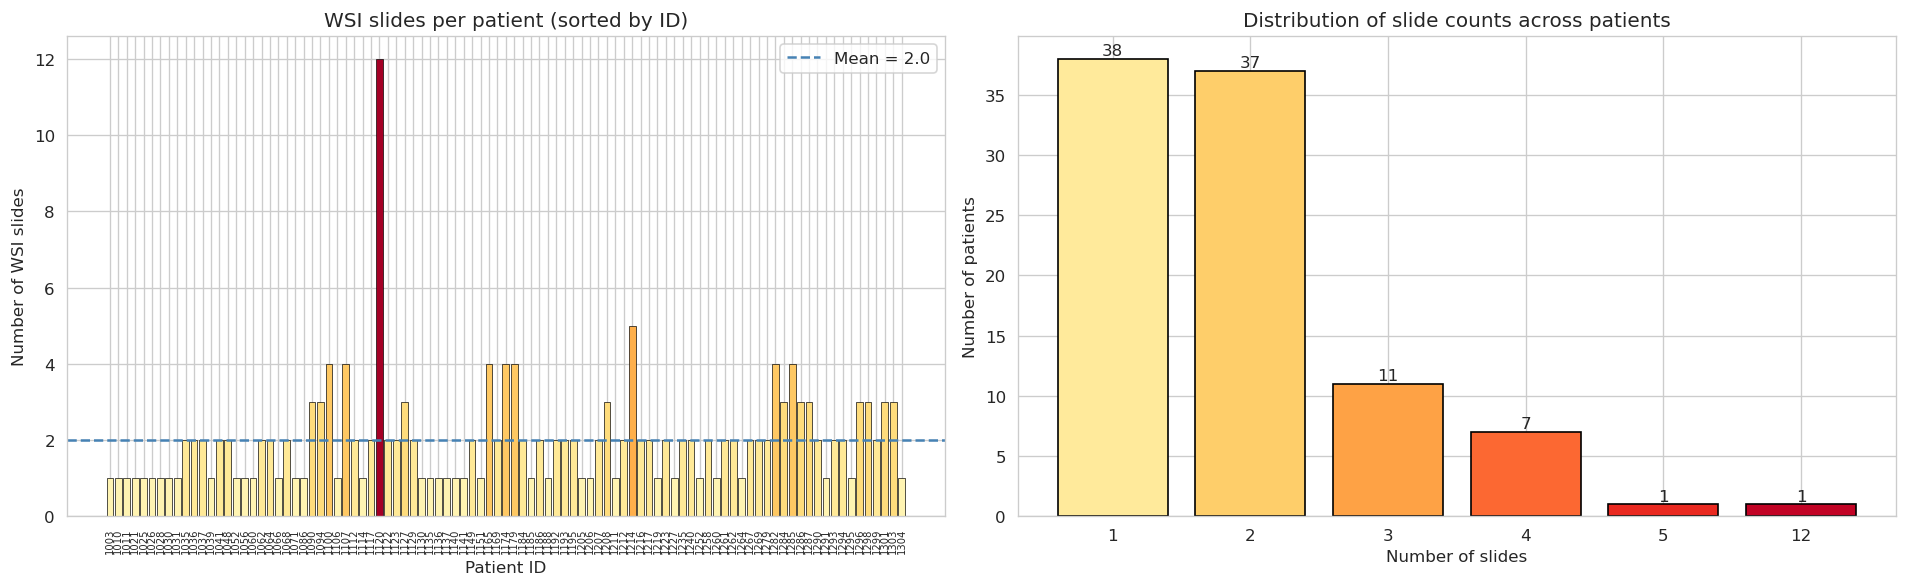

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (a) Slide count per patient — bar chart sorted by patient ID
ax = axes[0]
colors = sns.color_palette("YlOrRd", slide_df["n_slides"].max())
bar_colors = [colors[n - 1] for n in slide_df["n_slides"]]
ax.bar(slide_df["patient_id"].astype(str), slide_df["n_slides"],
       color=bar_colors, edgecolor="black", linewidth=0.4)
ax.set_xlabel("Patient ID")
ax.set_ylabel("Number of WSI slides")
ax.set_title("WSI slides per patient (sorted by ID)")
ax.set_xticks(range(len(slide_df)))
ax.set_xticklabels(slide_df["patient_id"].astype(str), rotation=90, fontsize=6)
ax.axhline(slide_df["n_slides"].mean(), color="steelblue", linestyle="--",
           linewidth=1.5, label=f"Mean = {slide_df['n_slides'].mean():.1f}")
ax.legend()

# (b) Histogram of slide count distribution
ax = axes[1]
count_hist = slide_df["n_slides"].value_counts().sort_index()
ax.bar(count_hist.index.astype(str), count_hist.values,
       color=sns.color_palette("YlOrRd", len(count_hist)), edgecolor="black")
for i, (n, v) in enumerate(count_hist.items()):
    ax.text(i, v + 0.3, str(v), ha="center", fontsize=10)
ax.set_xlabel("Number of slides")
ax.set_ylabel("Number of patients")
ax.set_title("Distribution of slide counts across patients")

plt.tight_layout()
plt.show()

---
## Section 9: Stratified Train Split for Preliminary Modelling

We want a small balanced training set of 20 patients (10 BCR+, 10 BCR-) for
preliminary model development.  The remaining 75 patients become the test set,
preserving the natural class distribution for realistic evaluation.

**Why stratified?**  With only 27 BCR+ patients, a random draw of 10 could
easily over-represent one clinical subgroup (e.g. all high-ISUP/late-stage)
and under-represent another.  We stratify on `ISUP_group × pT_group` so the
10 selected BCR+ patients mirror the joint distribution of the full 27.
The same logic is applied to BCR- to avoid a skewed negative set.

In [33]:
from sklearn.model_selection import StratifiedShuffleSplit

rng = np.random.RandomState(42)

# Build composite stratification key
df["ISUP_group"] = pd.cut(df["ISUP"], bins=[0, 2, 3, 5], labels=["1-2", "3", "4-5"])
df["pT_group"] = df["pT_stage"].apply(
    lambda x: "T2" if str(x).startswith("2") else ("T3" if str(x).startswith("3") else "T4"))
df["strat_key"] = df["ISUP_group"].astype(str) + "_" + df["pT_group"]

train_ids = []
for bcr_val in [0, 1]:
    sub = df[df["BCR"] == bcr_val].copy()
    strat = sub["strat_key"]

    # Some strata may be too small for a clean proportional split.
    # StratifiedShuffleSplit handles this gracefully by sampling at least 1
    # per stratum when possible.  If a stratum has only 1 member it may or
    # may not be selected — acceptable for a preliminary split.
    n_select = 10
    splitter = StratifiedShuffleSplit(n_splits=1, train_size=n_select, random_state=rng)
    sel_idx, _ = next(splitter.split(sub, strat))
    train_ids.extend(sub.iloc[sel_idx]["patient_id"].tolist())

df["split"] = df["patient_id"].apply(lambda x: "train" if x in train_ids else "test")

print(f"Train: {(df['split']=='train').sum()} patients  |  Test: {(df['split']=='test').sum()} patients")
print(f"\nTrain BCR distribution:\n{df.loc[df['split']=='train', 'BCR'].value_counts().sort_index().to_frame('n')}")
print(f"\nTest BCR distribution:\n{df.loc[df['split']=='test', 'BCR'].value_counts().sort_index().to_frame('n')}")

Train: 20 patients  |  Test: 75 patients

Train BCR distribution:
      n
BCR    
0    10
1    10

Test BCR distribution:
      n
BCR    
0    58
1    17


In [34]:
# Verify stratification quality: compare ISUP×pT distribution in selected vs full
print("=== BCR+ train (n=10) vs full (n=27) — ISUP × pT ===")
for label, subset in [("Full", df[df["BCR"] == 1]), ("Train", df[(df["BCR"] == 1) & (df["split"] == "train")])]:
    ct = pd.crosstab(subset["ISUP_group"], subset["pT_group"], margins=True)
    print(f"\n{label}:")
    print(ct)

print("\n=== BCR- train (n=10) vs full (n=68) — ISUP × pT ===")
for label, subset in [("Full", df[df["BCR"] == 0]), ("Train", df[(df["BCR"] == 0) & (df["split"] == "train")])]:
    ct = pd.crosstab(subset["ISUP_group"], subset["pT_group"], margins=True)
    print(f"\n{label}:")
    print(ct)

=== BCR+ train (n=10) vs full (n=27) — ISUP × pT ===

Full:
pT_group    T2  T3  T4  All
ISUP_group                 
1-2          4   3   0    7
3            2   6   3   11
4-5          4   3   2    9
All         10  12   5   27

Train:
pT_group    T2  T3  T4  All
ISUP_group                 
1-2          1   1   0    2
3            1   2   1    4
4-5          2   1   1    4
All          4   4   2   10

=== BCR- train (n=10) vs full (n=68) — ISUP × pT ===

Full:
pT_group    T2  T3  All
ISUP_group             
1-2         31  14   45
3            7   9   16
4-5          3   4    7
All         41  27   68

Train:
pT_group    T2  T3  All
ISUP_group             
1-2          5   2    7
3            1   1    2
4-5          0   1    1
All          6   4   10


In [35]:
# Save split assignments for downstream use
split_df = df[["patient_id", "BCR", "split", "ISUP_group", "pT_group"]].copy()
split_df.to_csv("../data/preliminary_split.csv", index=False)
print(f"Saved split assignments to ../data/preliminary_split.csv")
print(f"\nTrain patient IDs:\n{sorted(split_df.loc[split_df['split']=='train', 'patient_id'].tolist())}")

Saved split assignments to ../data/preliminary_split.csv

Train patient IDs:
['1036', '1041', '1060', '1090', '1100', '1122', '1129', '1130', '1137', '1140', '1169', '1179', '1186', '1205', '1208', '1219', '1258', '1264', '1284', '1303']


In [37]:
train = df[df["split"] == "train"]
print("BCR+ training samples:")
print(sorted(train.loc[train["BCR"] == 1, "patient_id"].tolist()))
print("\nBCR- training samples:")
print(sorted(train.loc[train["BCR"] == 0, "patient_id"].tolist()))

BCR+ training samples:
['1041', '1090', '1100', '1122', '1130', '1137', '1169', '1208', '1219', '1258']

BCR- training samples:
['1036', '1060', '1129', '1140', '1179', '1186', '1205', '1264', '1284', '1303']
